# Funzioni logaritmiche
Usiamo Sage per fare i grafici delle funzioni logaritmiche.

Il logaritmo $\log_a(x)$ si esprime con la funzione `log(x,a)` : 

In [1]:
log(4,2) 

2

In [2]:
log(1/3,3)

-1

Il logaritmo in base naturale, $\ln(x)$ si scrive `log(x)`

In [3]:
log(sqrt(e))

1/2

In [4]:
g(x)=log(x,2)  #funzione logaritmo in base 2
h(x)=log(x,1/2) #logaritmo in base 1/2

verbose 0 (3987: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 100 points.
verbose 0 (3987: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.007554613392424157)'
verbose 0 (3987: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 100 points.
verbose 0 (3987: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.009605167535729514)'


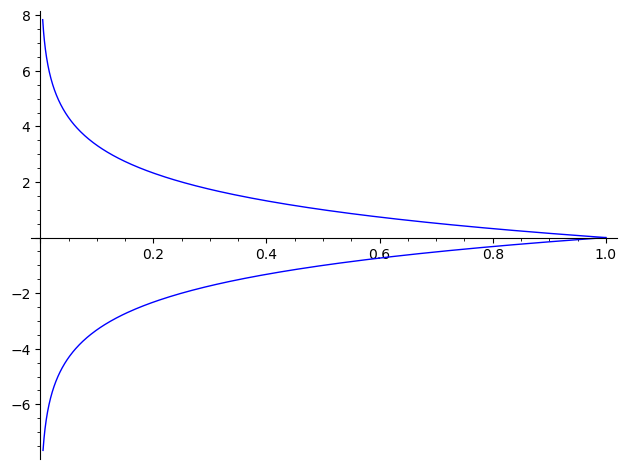

In [5]:
f1=plot(g)
f2=plot(h)
show(f1+f2)

In [6]:
@interact
def _(a=slider(1.01,3,step_size=0.01)):
    p1=plot(log(x,a),(x,0, 8),ymin=-10,ymax=10, color='red',legend_label='base $a$')
    p2=plot(log(x,1/a),(x,0, 8),ymin=-10,ymax=10, color='green',legend_label='base $1/a$')
    show(p1+p2,figsize=[6,3])

Interactive function <function _ at 0x15d53aac0> with 1 widget
  a: TransformFloatSlider(value=1.01, description='a', max=3.0, min=1.01, step=0.01)

## Disequazioni logaritmiche

Risolvere $$\ln(x+5) - \ln(4-x) + \ln(3x-1) > \ln(3x - 1) - \ln(x+4) $$

Svolgimento:

1) Condizioni di esistenza:
\begin{align*}
\begin{cases}
x+5>0\\
4-x>0\\
3x-1>0\\
x+4>0
\end{cases}
\iff
\begin{cases}
x>-5\\
x<4\\
x>1/3\\
x>-4
\end{cases}
\iff \frac 13 < x<4
\end{align*}

2) Semplifichiamo usando le proprietà dei logaritmi:
\begin{align*}
\ln(x+5)+\ln(x+4)&>\ln(4-x)\\
\ln((x+5)\cdot(x+4))&>\ln(4-x)
\end{align*}

3) Siccome la base è $e>1$, possiamo passare alla disuguaglianza tra gli argomenti, senza cambiare il verso:
\begin{align*}
&(x+5)\cdot(x+4)>4-x\\
&x^2+9x+20+x-4>0\\
&x^2+10x+16>0
\end{align*}

$\Delta=100-4\cdot 16=36\implies \ x_1=-8,\ x_2=-2$
Le soluzioni della funzione quadratica sono: $x<-8\ \lor\ x>-2$

4) Tenendo conto delle condizioni di esistenza abbiamo le soluzioni:
   $\frac 13 < x <4$
 

Vediamo ora come risolvere con Sage

In [7]:
%display latex
dis=log(x+5) - log(4-x) + log(3*x-1) > log(3*x - 1) - log(x+4)
dis

log(3*x - 1) + log(x + 5) - log(-x + 4) > log(3*x - 1) - log(x + 4)

In [8]:
solve(dis,algorithm='sympy')

[[x > -2], [x < 4]]

Risolviamo facendo tutti i passaggi. Per prima cosa calcoliamo le condizioni di esistenza:

In [9]:
ce=solve([x+5>0,4-x>0,3*x-1>0,x+4>0])
ce

[[(1/3) < x, x < 4]]

Questo equivale a $\frac13 <x<4$, infatti:

In [10]:
load('utils_DP.sage')
interval_sol(ce)

(1/3, 4)

Ora semplifichiamo cancellando i termini uguali e usando le proprietà dei logaritmi:

In [12]:
show(dis)
dis1=dis-log(3*x-1)+log(x+4)
show(dis1)

log(3*x - 1) + log(x + 5) - log(-x + 4) > log(3*x - 1) - log(x + 4)

log(x + 5) + log(x + 4) - log(-x + 4) > 0

In [13]:
dis2=dis1.log_simplify()
dis2

log(-(x + 5)*(x + 4)/(x - 4)) > 0

Ricordandoci che $0=\log(1)$, passiamo alla disuguaglianza tra gli argomenti, senza cambiare il verso, base $e> 1$

In [14]:
dis3=-(x+5)*(x+4)/(x-4)>1
dis3

-(x + 5)*(x + 4)/(x - 4) > 1

In [15]:
dis4=dis3-1
dis4.factor()

-(x^2 + 10*x + 16)/(x - 4) > 0

In [16]:
interval_sol(solve(dis4))

(-oo, -8) ∪ (-2, 4)

In [17]:
sol=solve([dis3,ce[0][0],ce[0][1]])
interval_sol(sol)

(1/3, 4)